## Imports

In [1]:
import mesmer
import model
import model_analysis

import importlib
import matplotlib.pyplot as plt
import xarray as xr

import cartopy.crs as ccrs



### Updates (temp)

In [24]:
importlib.reload(model.stats);
importlib.reload(model.shape_data);
importlib.reload(model.transform);



## Load Data

In [3]:
is_local_data = False

In [4]:
mean_mrsol_ds = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=1)
mean_mrsol_ds = model.shape_data.prune_group_ds_timespan(mean_mrsol_ds,Month_idx=1).drop_vars("depth_bnds")

var_mrsol_ds = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=2)
var_mrsol_ds = model.shape_data.prune_group_ds_timespan(var_mrsol_ds,Month_idx=1).drop_vars("depth_bnds")

#Wenn man sicher gehen will, das der Predictor die testdaten nicht kennen soll, kann man die testdaten auch erst nach dem Calibrieren berechnen
test_mrsol_ds = model.shape_data.load_data_set(var = "mrsol", local = is_local_data, run_idx=3)
test_mrsol_ds = model.shape_data.prune_group_ds_timespan(test_mrsol_ds,Month_idx=1).drop_vars("depth_bnds")

In [5]:
tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=1)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=1)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=1)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=1)

mean_input_ds = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=2)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=2)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=1)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=1)

var_input_ds = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")

tas_ds = model.shape_data.load_data_set(var = "tas", local = is_local_data, run_idx=3)
pr_ds = model.shape_data.load_data_set(var = "pr", local = is_local_data, run_idx=3)
tas_ds = model.shape_data.prune_group_ds_timespan(tas_ds,Month_idx=1)
pr_ds = model.shape_data.prune_group_ds_timespan(pr_ds,Month_idx=1)

test_input_ds = xr.merge([tas_ds,pr_ds]).drop_vars("file_qf")


### Mask and Stack Data

In [6]:
mean_mrsol_masked_ds, chunk_mask, detail_mask_mean = model.mask.mask_nonpositiv_height_chunks(mean_mrsol_ds)
mean_input_masked_ds = model.mask.mask_mask(mean_input_ds,chunk_mask)

var_mrsol_masked_ds , chunk_mask_var, detail_mask_mean = model.mask.mask_nonpositiv_height_chunks(var_mrsol_ds)
var_input_masked_ds = model.mask.mask_mask(var_input_ds,chunk_mask)

test_mrsol_masked_ds, chunk_mask_test, detail_mask_mean= model.mask.mask_nonpositiv_height_chunks(test_mrsol_ds)
test_input_masked_ds = model.mask.mask_mask(test_input_ds,chunk_mask)

In [7]:
#The chunk_mask schould all be the same, this is important that there are no shape problems in the regressions, you can test this with  
#(chunk_mask != chunk_mask_2).sum(),#(chunk_mask != chunk_mask_1).sum(),
#The chunk_mask is used, that the regression can predict a depth.size vector at each gridcell, the masks: detail_mask_mean, detail_mask_var and detail_mask_test are later used to determan which points are real predictions and witch where just placeholders to let the regression run smoothly.

In [8]:
mean_mrsol_stack_ds = mesmer.grid.stack_lat_lon(mean_mrsol_masked_ds)
var_mrsol_stack_ds = mesmer.grid.stack_lat_lon(var_mrsol_masked_ds)
test_mrsol_stack_ds = mesmer.grid.stack_lat_lon(test_mrsol_masked_ds)
mean_input_stack_ds = mesmer.grid.stack_lat_lon(mean_input_masked_ds)
var_input_stack_ds = mesmer.grid.stack_lat_lon(var_input_masked_ds)
test_input_stack_ds = mesmer.grid.stack_lat_lon(test_input_masked_ds)

### Transform Data

In [9]:
mean_mrsol_t = model.transform.Log_Transform_ds(mean_mrsol_stack_ds)
var_mrsol_t = model.transform.Log_Transform_ds(var_mrsol_stack_ds)
test_mrsol_t = model.transform.Log_Transform_ds(test_mrsol_stack_ds)

### Linaer Regression of the mean

In [10]:
mean_predictors = mean_input_stack_ds
mean_target_da = mean_mrsol_t.mrsol

In [11]:
LinReg_mean = model.stats._parallel_linear_regression.ParLinearRegression()

In [12]:
LinReg_mean.fit(predictors=mean_predictors, target=mean_target_da,location_dim="gridcell", regr_dim="time")

In [13]:
#LinReg_mean.params

### Compute Residuals for the variance

Hier wäre die meinung einen neuen Run zu verwenden, die frage ist ob sich die variance durch das fehlen des runs zu tief ausfällt. Overfitting korrektur mit 1/(1-param/n_samples)^2? (SPäter probieren)

In [14]:
var_predictors = var_input_stack_ds
var_target_ds = var_mrsol_t

In [15]:
residuals_t = LinReg_mean.residuals(var_predictors, var_target_ds)

In [16]:
residuals_t

<xarray.Dataset> Size: 19MB
Dimensions:    (depth: 5, time: 165, gridcell: 2935)
Coordinates:
  * depth      (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
  * time       (time) datetime64[ns] 1kB 1850-01-31 1851-01-31 ... 2014-01-31
    lat        (gridcell) float64 23kB -56.25 -56.25 -56.25 ... 81.25 81.25
    lon        (gridcell) float64 23kB 288.8 291.2 293.8 ... 293.8 296.2 298.8
    height     float64 8B 2.0
Dimensions without coordinates: gridcell
Data variables:
    residuals  (time, depth, gridcell) float64 19MB -0.03847 ... -2.132e-14

### Linear Regression of the Variance

In [17]:
LinReg_variance = model.stats._parallel_linear_regression.ParLinearRegression()

In [18]:
LinReg_variance.fit(predictors=var_predictors, target=(residuals_t.residuals)**2,location_dim="gridcell", regr_dim="time")

### Predictor

In [19]:
LinReg_mean, LinReg_variance

(<model.stats._parallel_linear_regression.ParLinearRegression at 0x7ff80c1427b0>,
 <model.stats._parallel_linear_regression.ParLinearRegression at 0x7ff7d9330050>)

### Export Prameters

In [ ]:
#model.save.save_params(LinReg_mean.params,LinReg_variance.params,var = "mrsol",scen= "historical", folder = "MPI-ESM1-2-LR/Log-trans")

In [ ]:
#model.shape_data.load_params(var = "mrsol",scen= "historical", folder = "MPI-ESM1-2-LR/Log-trans")

(<xarray.Dataset> Size: 399kB
 Dimensions:        (gridcell: 2935, depth: 5)
 Coordinates:
     lat            (gridcell) float64 23kB -56.25 -56.25 -56.25 ... 81.25 81.25
     lon            (gridcell) float64 23kB 288.8 291.2 293.8 ... 296.2 298.8
   * depth          (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
 Dimensions without coordinates: gridcell
 Data variables:
     intercept      (gridcell, depth) float64 117kB -1.594 3.292 ... 3.564 -9.21
     tas            (gridcell, depth) float64 117kB 0.01356 ... -5.05e-29
     pr             (gridcell, depth) float64 117kB 3.63e+03 ... 3.589e-23
     fit_intercept  bool 1B True,
 <xarray.Dataset> Size: 399kB
 Dimensions:        (gridcell: 2935, depth: 5)
 Coordinates:
     lat            (gridcell) float64 23kB -56.25 -56.25 -56.25 ... 81.25 81.25
     lon            (gridcell) float64 23kB 288.8 291.2 293.8 ... 296.2 298.8
   * depth          (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
 Dimensions without coordinates: gridcell
 Data

### Example Emulation

In [84]:
test_predictors = test_input_stack_ds
test_target_ds = test_mrsol_t.transpose("gridcell","time", "depth")

In [85]:
test_mean_prediction_stacked = LinReg_mean.predict(test_predictors).transpose("gridcell","time", "depth")

In [86]:
test_var_prediction_stacked = LinReg_variance.predict(test_predictors).clip(min = 1e-32).transpose("gridcell","time", "depth")

### crpss Score

In [87]:
#temp
importlib.reload(model_analysis.crps_score);

scheinbar wächst die laufzeit in der ensemble_size mehr als linear, sieht schlimmer als quadratisch aus:(

5->0.5s

10->1.3s

20->4.2s

40->15s

80->1min 54s

In [88]:
score_stacked, space_score_stacked = model_analysis.crps_score.crps_ensemble_score(test_mean_prediction_stacked, test_var_prediction_stacked,test_target_ds,transformation="Log",ensemble_size=10)

In [89]:
score_stacked

<xarray.Dataset> Size: 19MB
Dimensions:     (depth: 5, time: 165, gridcell: 2935)
Coordinates:
  * depth       (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
  * time        (time) datetime64[ns] 1kB 1850-01-31 1851-01-31 ... 2014-01-31
    lat         (gridcell) float64 23kB -56.25 -56.25 -56.25 ... 81.25 81.25
    lon         (gridcell) float64 23kB 288.8 291.2 293.8 ... 293.8 296.2 298.8
Dimensions without coordinates: gridcell
Data variables:
    crps_score  (depth, time, gridcell) float64 19MB 0.09667 ... 8.651e-19

In [90]:
score = mesmer.grid.unstack_lat_lon_and_align(mean_mrsol_stack_ds,mean_mrsol_masked_ds)

In [91]:
score = score.rename_vars({"mrsol": "crps_score"})

In [92]:
score.isel(depth=0).mean("time")

<xarray.Dataset> Size: 85kB
Dimensions:     (lat: 72, lon: 144)
Coordinates:
  * lat         (lat) float64 576B -88.75 -86.25 -83.75 ... 83.75 86.25 88.75
  * lon         (lon) float64 1kB 1.25 3.75 6.25 8.75 ... 353.8 356.2 358.8
    depth       float64 8B 0.03
Data variables:
    crps_score  (lat, lon) float64 83kB nan nan nan nan nan ... nan nan nan nan
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Mon Mar 01 09:46:00 2021: cdo -O -b F64 -remap...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/0fd5d006-722a-4650-a835-398b6aae92c9
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Emon/mrsol/MP...
    original_file_hash_codes:  35dde960416cda436bd90358a67f602de138e51219997c...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

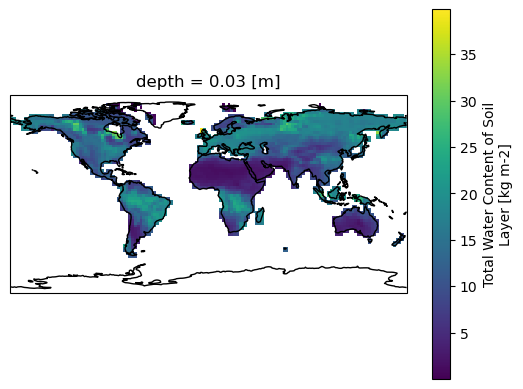

In [93]:
fig, ax = plt.subplots(
    subplot_kw={"projection": ccrs.PlateCarree()}
)

da = score.isel(depth=0).mean("time").crps_score
da.plot(ax=ax)

ax.coastlines()

